# Quantum Oracle Sketching (QOS) - Demo Notebook

This notebook demonstrates the core ideas from the paper *"Exponential quantum advantage in processing massive classical data"* (arXiv:2604.07639).

## What is QOS?

Quantum Oracle Sketching is a framework that loads classical data into a quantum computer using **only random samples** from the data, without requiring the full dataset to be stored in quantum memory. This achieves an **exponential memory advantage** over classical methods.

## Notebook Outline

1. **Setup & Imports**
2. **Part A: Boolean Phase Oracle Sketch** - Sketch a phase oracle for a Boolean function
3. **Part B: General Vector State Sketch** - Prepare a quantum state from a classical vector
4. **Part C: Sparse Matrix Element Oracle** - Sketch element-wise oracles for sparse matrices
5. **Part D: Amplitude Amplification** - Boost success probability via QSVT
6. **Part E: Error Scaling Analysis** - How error decreases with sample size
7. **Part F: Block Encoding from Sparse Oracles** - Full matrix block encoding pipeline

## 1. Setup & Imports

In [22]:
import sys
from pathlib import Path

# Add repo root to path
ROOT = Path.cwd().resolve()
if not (ROOT / "qos.py").exists() and (ROOT.parent / "qos.py").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import jax
import jax.numpy as jnp
from jax import random
import numpy as np
import matplotlib.pyplot as plt
import time

import qos
import utils
import primitives

print(f"JAX version: {jax.__version__}")
print(f"JAX backend: {jax.default_backend()}")
print(f"64-bit enabled: {jax.config.x64_enabled}")
print(f"Repository root: {ROOT}")

JAX version: 0.8.1
JAX backend: cpu
64-bit enabled: True
Repository root: /mnt/Shared/cmrunner/21_study/QuantumHackthon/Quafu/final/code/Quafu-sqc-quantum-oracle-sketching


---
## 2. Part A: Boolean Phase Oracle Sketch

### Idea
Given a Boolean function $f: \{0,1\}^n \to \{0,1\}$, we want to construct the phase oracle:
$$U_f = \text{diag}(e^{i\pi f(0)}, e^{i\pi f(1)}, \ldots, e^{i\pi f(N-1)})$$

QOS constructs an approximation $\tilde{U}_f$ using only $M$ random samples, where the error scales as $O(1/\sqrt{M})$.

### Implementation
The key function is `qos.q_oracle_sketch_boolean(truth_table, unit_num_samples)`.

In [23]:
# Generate a random Boolean function on 2^n inputs
n_qubits = 6  # 2^6 = 64 inputs
dim = 2 ** n_qubits

key = random.PRNGKey(42)
key, subkey = random.split(key)
truth_table = random.randint(subkey, (dim,), minval=0, maxval=2, dtype=utils.int_dtype)

# Target phase oracle
target_oracle = jnp.exp(1j * jnp.pi * truth_table)

print(f"Boolean function dimension: {dim}")
print(f"Truth table (first 16): {truth_table[:16]}")
print(f"Target phases (first 8): {target_oracle[:8]}")

Boolean function dimension: 64
Truth table (first 16): [1 0 0 0 1 0 1 0 0 1 0 0 0 1 1 0]
Target phases (first 8): [-1.+1.2246468e-16j  1.+0.0000000e+00j  1.+0.0000000e+00j
  1.+0.0000000e+00j -1.+1.2246468e-16j  1.+0.0000000e+00j
 -1.+1.2246468e-16j  1.+0.0000000e+00j]


In [24]:
# Sketch the Boolean oracle with different sample sizes
sample_sizes = [1_000, 5_000, 20_000, 100_000]

print("M (samples) | Max Error | Samples Used")
print("-" * 45)

errors_bool = []
for M in sample_sizes:
    diag_est, samples_used = qos.q_oracle_sketch_boolean(truth_table, M)
    error = float(jnp.max(jnp.abs(diag_est - target_oracle)))
    errors_bool.append(error)
    print(f"{M:>11,} | {error:.4e} | {samples_used:>11,}")

M (samples) | Max Error | Samples Used
---------------------------------------------
      1,000 | 2.6707e-01 |       1,000
      5,000 | 6.0283e-02 |       5,000
     20,000 | 1.5424e-02 |      20,000
    100,000 | 3.1041e-03 |     100,000


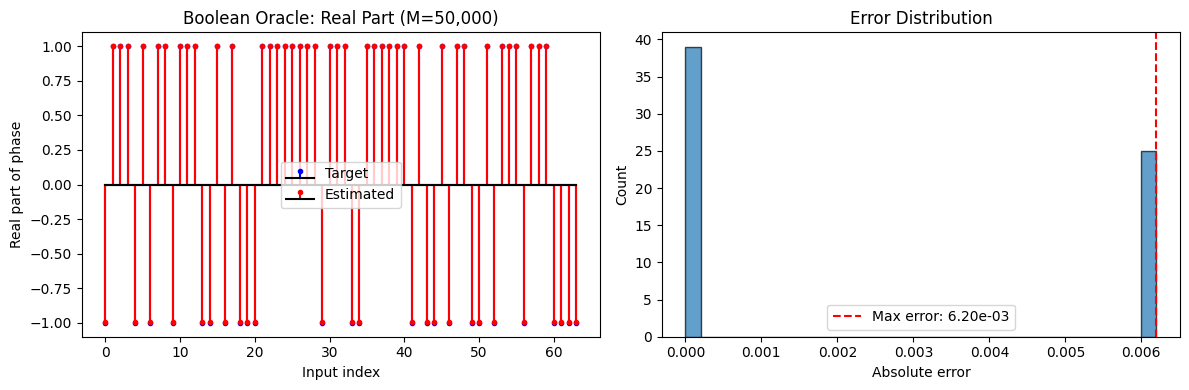

In [25]:
# Visualize: compare estimated vs target phases
M_demo = 50_000
diag_est, _ = qos.q_oracle_sketch_boolean(truth_table, M_demo)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Real parts
axes[0].stem(range(dim), np.array(jnp.real(target_oracle)), linefmt='b-', markerfmt='b.', basefmt='k-', label='Target')
axes[0].stem(range(dim), np.array(jnp.real(diag_est)), linefmt='r-', markerfmt='r.', basefmt='k-', label='Estimated')
axes[0].set_xlabel('Input index')
axes[0].set_ylabel('Real part of phase')
axes[0].set_title(f'Boolean Oracle: Real Part (M={M_demo:,})')
axes[0].legend()

# Error distribution
errors_per_element = np.array(jnp.abs(diag_est - target_oracle))
axes[1].hist(errors_per_element, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(float(jnp.max(errors_per_element)), color='r', linestyle='--', label=f'Max error: {float(jnp.max(errors_per_element)):.2e}')
axes[1].set_xlabel('Absolute error')
axes[1].set_ylabel('Count')
axes[1].set_title('Error Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 3. Part B: General Vector State Sketch

### Idea
Given a classical vector $\mathbf{v} \in \mathbb{R}^N$, we want to prepare the quantum state:
$$|\psi\rangle = \frac{1}{\|\mathbf{v}\|} \sum_{i=0}^{N-1} v_i |i\rangle$$

QOS achieves this using $M$ random samples of vector components, leveraging QSVT (Quantum Singular Value Transform) to approximate the arcsin function.

### Key function: `qos.q_state_sketch(vector, key, unit_num_samples)`

In [26]:
# Generate a random real vector
dim_vec = 64
key, subkey = random.split(key)
vector = random.normal(subkey, (dim_vec,), dtype=utils.real_dtype)
vector = vector / jnp.linalg.norm(vector)  # normalize

print(f"Vector dimension: {dim_vec}")
print(f"Vector norm: {jnp.linalg.norm(vector):.6f}")
print(f"First 8 components: {vector[:8]}")

Vector dimension: 64
Vector norm: 1.000000
First 8 components: [ 0.04663579  0.02035796  0.21966772 -0.14518574  0.05233593  0.16357961
 -0.12759009  0.02677455]


In [27]:
# Sketch the state
M_state = 10_000

key, subkey = random.split(key)
t0 = time.time()
with utils.suppress_stdout_stderr():
    state_est, samples_used = qos.q_state_sketch(
        vector, key=subkey, unit_num_samples=M_state, degree=10
    )
t1 = time.time()

# Compute errors
state_norm = float(jnp.linalg.norm(state_est))
state_dir = state_est / state_norm
target_dir = vector / jnp.linalg.norm(vector)
l2_error = float(jnp.linalg.norm(state_dir - target_dir))

print(f"Samples used: {samples_used:,}")
print(f"Output state norm (success prob): {state_norm:.4f}")
print(f"L2 direction error: {l2_error:.4e}")
print(f"Time: {t1 - t0:.2f}s")

Samples used: 90,000
Output state norm (success prob): 0.1272
L2 direction error: 2.7945e-05
Time: 0.02s


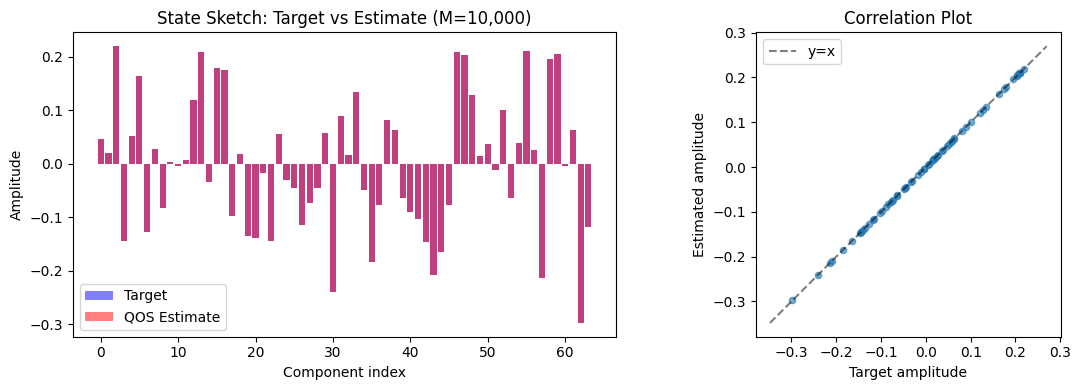

In [28]:
# Visualize state sketch result
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x_idx = range(dim_vec)
target_np = np.array(target_dir)
state_np = np.array(state_dir)

# Compare components
axes[0].bar(x_idx, target_np, alpha=0.5, label='Target', color='blue')
axes[0].bar(x_idx, state_np, alpha=0.5, label='QOS Estimate', color='red')
axes[0].set_xlabel('Component index')
axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'State Sketch: Target vs Estimate (M={M_state:,})')
axes[0].legend()

# Scatter plot: target vs estimated
axes[1].scatter(target_np, state_np, alpha=0.6, s=20)
lims = [
    min(target_np.min(), state_np.min()) - 0.05,
    max(target_np.max(), state_np.max()) + 0.05,
]
axes[1].plot(lims, lims, 'k--', alpha=0.5, label='y=x')
axes[1].set_xlabel('Target amplitude')
axes[1].set_ylabel('Estimated amplitude')
axes[1].set_title('Correlation Plot')
axes[1].legend()
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

---
## 4. Part C: Sparse Matrix Element Oracle

### Idea
For a sparse matrix $A \in \mathbb{R}^{m \times n}$, we construct a Hermitian block encoding of the element oracle:
$$O_A: |i\rangle|j\rangle \mapsto A_{ij} |i\rangle|j\rangle$$

QOS samples non-zero elements uniformly at random to build this oracle.

### Key function: `qos.q_oracle_sketch_matrix_element(matrix, unit_num_samples)`

Matrix shape: (24, 24)
Non-zeros: 111
Max |entry|: 0.4964


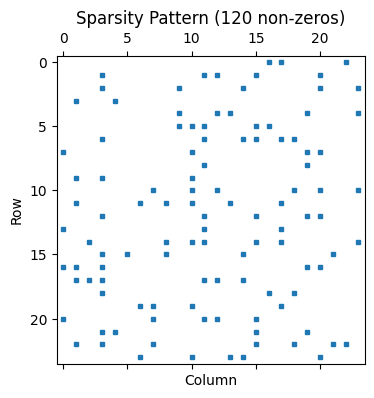

In [29]:
# Generate a random sparse matrix
m, n = 24, 24
nnz = 120  # number of non-zeros

key, subkey = random.split(key)
A = utils.random_sparse_matrix_constant_magnitude(
    subkey, (m, n), nnz=nnz, magnitude=0.5
)

print(f"Matrix shape: {A.shape}")
print(f"Non-zeros: {int(jnp.count_nonzero(A))}")
print(f"Max |entry|: {float(jnp.max(jnp.abs(A))):.4f}")

# Visualize sparsity pattern
plt.figure(figsize=(5, 4))
plt.spy(np.array(A != 0), markersize=3)
plt.title(f'Sparsity Pattern ({nnz} non-zeros)')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

In [30]:
# Sketch the matrix element oracle
M_matrix = 100_000

t0 = time.time()
diag_est, samples_used = qos.q_oracle_sketch_matrix_element(A, unit_num_samples=M_matrix)
t1 = time.time()

target_diag = A.reshape(-1)
max_error = float(jnp.max(jnp.abs(diag_est - target_diag)))

print(f"Samples used: {samples_used:,}")
print(f"Max element-wise error: {max_error:.4e}")
print(f"Time: {t1 - t0:.2f}s")

Samples used: 100,000
Max element-wise error: 7.3688e-05
Time: 0.00s


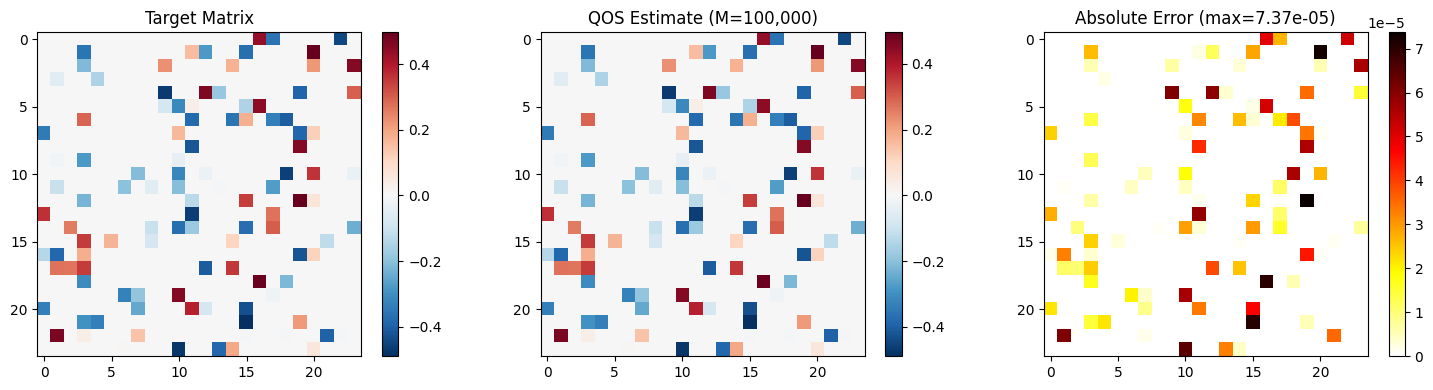

In [31]:
# Visualize matrix element oracle reconstruction
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

target_2d = np.array(target_diag).reshape(m, n)
est_2d = np.array(jnp.real(diag_est)).reshape(m, n)
error_2d = np.array(jnp.abs(diag_est - target_diag)).reshape(m, n)

im0 = axes[0].imshow(target_2d, cmap='RdBu_r', aspect='equal')
axes[0].set_title('Target Matrix')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(est_2d, cmap='RdBu_r', aspect='equal')
axes[1].set_title(f'QOS Estimate (M={M_matrix:,})')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(error_2d, cmap='hot_r', aspect='equal')
axes[2].set_title(f'Absolute Error (max={max_error:.2e})')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

---
## 5. Part D: Amplitude Amplification via QSVT

### Idea
After QOS, the output state often has small norm (low success probability). **Amplitude amplification** using QSVT's sign function boosts the norm close to 1, similar to Grover's algorithm but more general.

### Key function: `primitives.amplitude_amplification(unnormalized_state, degree, target_norm)`

In [32]:
# Create a low-norm state (simulating poor QOS output)
dim_aa = 100
key, subkey = random.split(key)
v_low = random.normal(subkey, (dim_aa,), dtype=utils.real_dtype)
v_low = v_low / jnp.linalg.norm(v_low) * 0.15  # norm = 0.15

print(f"Initial norm: {jnp.linalg.norm(v_low):.4f}")
print(f"Initial success probability: {jnp.linalg.norm(v_low)**2:.4f}")

Initial norm: 0.1500
Initial success probability: 0.0225


In [33]:
# Apply amplitude amplification
degree_aa = 51
target_norm = 0.99

t0 = time.time()
with utils.suppress_stdout_stderr():
    v_amplified = primitives.amplitude_amplification(
        v_low, degree=degree_aa, target_norm=target_norm
    )
t1 = time.time()

final_norm = float(jnp.linalg.norm(v_amplified))
direction_error = float(jnp.linalg.norm(
    v_low / jnp.linalg.norm(v_low) - v_amplified / jnp.linalg.norm(v_amplified)
))

print(f"Final norm: {final_norm:.4f} (target: {target_norm})")
print(f"Direction preservation error: {direction_error:.4e}")
print(f"Boost factor: {final_norm / float(jnp.linalg.norm(v_low)):.1f}x")
print(f"Time: {t1 - t0:.2f}s")

Final norm: 0.9354 (target: 0.99)
Direction preservation error: 4.1986e-15
Boost factor: 6.2x
Time: 0.18s


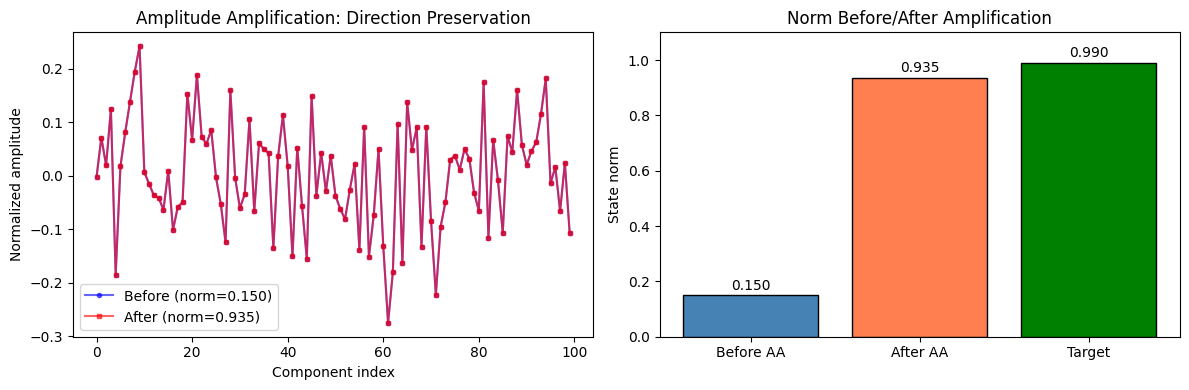

In [34]:
# Visualize amplitude amplification
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x_idx = range(dim_aa)

# Before and after (take real part for plotting)
v_low_np = np.real(np.array(v_low / jnp.linalg.norm(v_low)))
v_amp_np = np.real(np.array(v_amplified / jnp.linalg.norm(v_amplified)))

axes[0].plot(x_idx, v_low_np, 'b-o', markersize=3, alpha=0.6, label=f'Before (norm={float(jnp.linalg.norm(v_low)):.3f})')
axes[0].plot(x_idx, v_amp_np, 'r-s', markersize=3, alpha=0.6, label=f'After (norm={final_norm:.3f})')
axes[0].set_xlabel('Component index')
axes[0].set_ylabel('Normalized amplitude')
axes[0].set_title('Amplitude Amplification: Direction Preservation')
axes[0].legend()

# Norm comparison
norms = [float(jnp.linalg.norm(v_low)), final_norm, target_norm]
labels = ['Before AA', 'After AA', 'Target']
colors = ['steelblue', 'coral', 'green']
bars = axes[1].bar(labels, norms, color=colors, edgecolor='black')
axes[1].set_ylabel('State norm')
axes[1].set_title('Norm Before/After Amplification')
axes[1].set_ylim(0, 1.1)
for bar, val in zip(bars, norms):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## 6. Part E: Error Scaling Analysis

### Theory
The QOS error for a Boolean oracle scales as:
$$\epsilon \sim C \cdot M^{-\beta}$$
where $M$ is the number of samples and $\beta \approx 0.5$ (theoretical prediction).

We verify this by sweeping over sample sizes and fitting in log-log space.

In [35]:
# Error scaling for Boolean oracle
dim_scaling = 64
key, subkey = random.split(key)
truth_table_scaling = random.randint(subkey, (dim_scaling,), minval=0, maxval=2, dtype=utils.int_dtype)
target_scaling = jnp.exp(1j * jnp.pi * truth_table_scaling)

sample_sizes = np.array([1_000, 2_000, 5_000, 10_000, 20_000, 50_000, 100_000], dtype=float)
errors_scaling = []

print("Sweeping sample sizes...")
for M in sample_sizes:
    est, _ = qos.q_oracle_sketch_boolean(truth_table_scaling, int(M))
    err = float(jnp.max(jnp.abs(est - target_scaling)))
    errors_scaling.append(err)
    print(f"  M={int(M):>8,d} -> error={err:.4e}")

errors_scaling = np.array(errors_scaling)

Sweeping sample sizes...
  M=   1,000 -> error=2.6707e-01
  M=   2,000 -> error=1.4394e-01
  M=   5,000 -> error=6.0283e-02
  M=  10,000 -> error=3.0611e-02
  M=  20,000 -> error=1.5424e-02
  M=  50,000 -> error=6.1986e-03
  M= 100,000 -> error=3.1041e-03


In [36]:
# Fit power law: log(error) = intercept + slope * log(M)
log_m = np.log(sample_sizes)
log_e = np.log(errors_scaling)
slope, intercept = np.polyfit(log_m, log_e, deg=1)

beta = -slope
C = float(np.exp(intercept))
fit_errors = C * sample_sizes ** slope

# R^2 in log space
log_pred = slope * log_m + intercept
ss_res = float(np.sum((log_e - log_pred) ** 2))
ss_tot = float(np.sum((log_e - np.mean(log_e)) ** 2))
r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float('nan')

print(f"Fitted exponent beta = {beta:.4f} (theoretical: 0.5)")
print(f"Fitted prefactor C = {C:.4e}")
print(f"Log-space R^2 = {r2:.4f}")

Fitted exponent beta = 0.9713 (theoretical: 0.5)
Fitted prefactor C = 2.2900e+02
Log-space R^2 = 0.9997


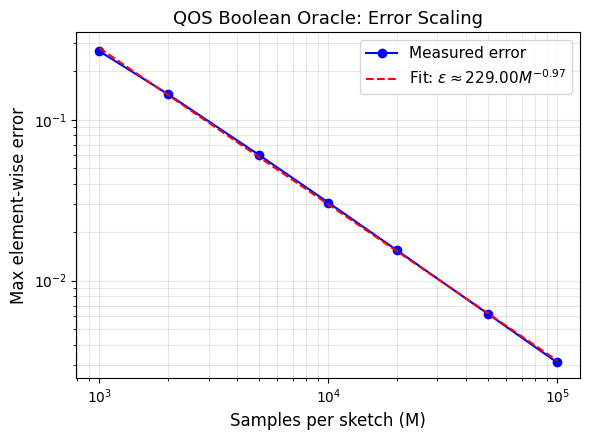


Detailed results:
         M |        Error |          Fit
----------------------------------------
     1,000 |   2.6707e-01 |   2.7927e-01
     2,000 |   1.4394e-01 |   1.4244e-01
     5,000 |   6.0283e-02 |   5.8498e-02
    10,000 |   3.0611e-02 |   2.9837e-02
    20,000 |   1.5424e-02 |   1.5219e-02
    50,000 |   6.1986e-03 |   6.2499e-03
   100,000 |   3.1041e-03 |   3.1878e-03


In [37]:
# Plot error scaling
plt.figure(figsize=(6, 4.5))
plt.loglog(sample_sizes, errors_scaling, 'bo-', linewidth=1.5, markersize=6, label='Measured error')
plt.loglog(
    sample_sizes, fit_errors, 'r--', linewidth=1.5,
    label=f'Fit: $\\epsilon \\approx {C:.2f} M^{{{-beta:.2f}}}$'
)
plt.xlabel('Samples per sketch (M)', fontsize=12)
plt.ylabel('Max element-wise error', fontsize=12)
plt.title('QOS Boolean Oracle: Error Scaling', fontsize=13)
plt.grid(True, which='both', alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\nDetailed results:")
print(f"{'M':>10} | {'Error':>12} | {'Fit':>12}")
print("-" * 40)
for m, e, ef in zip(sample_sizes.astype(int), errors_scaling, fit_errors):
    print(f"{m:>10,d} | {e:>12.4e} | {ef:>12.4e}")

---
## 7. Part F: Block Encoding from Sparse Oracles

### Idea
The full QOS pipeline for a sparse matrix $A$ constructs three oracles:
1. **Element oracle**: $|i\rangle|j\rangle \mapsto A_{ij}|i\rangle|j\rangle$
2. **Row index oracle**: $|i\rangle|k\rangle|0\rangle \mapsto |i\rangle|k\rangle|j(i,k)\rangle$
3. **Column index oracle**: $|j\rangle|k\rangle|0\rangle \mapsto |j\rangle|k\rangle|i(j,k)\rangle$

These are combined via Lemma 48 of [arXiv:1806.01838](https://arxiv.org/abs/1806.01838) to form a block encoding of $A$.

### Key function: `utils.block_encoding_from_sparse_oracles(row_oracle, col_oracle, elem_oracle)`

In [38]:
# Small sparse matrix for full pipeline demo
dim1, dim2 = 16, 16
nnz_full = 48
M_full = 500_000

key, subkey = random.split(key)
A_full = utils.random_sparse_matrix(subkey, (dim1, dim2), nnz_full)

row_sparsity = int(jnp.max(jnp.count_nonzero(A_full, axis=1)))
col_sparsity = int(jnp.max(jnp.count_nonzero(A_full, axis=0)))

print(f"Matrix: {dim1}x{dim2}, nnz={int(jnp.count_nonzero(A_full))}")
print(f"Row sparsity: {row_sparsity}, Col sparsity: {col_sparsity}")

Matrix: 16x16, nnz=45
Row sparsity: 5, Col sparsity: 6


In [39]:
# Step 1: Element oracle
print("Constructing element oracle...")
t0 = time.time()
element_oracle, n_elem = qos.q_oracle_sketch_matrix_element(A_full, M_full)
print(f"  Samples: {n_elem:,}, Time: {time.time() - t0:.2f}s")

# Step 2: Row index oracle
print("Constructing row index oracle...")
t0 = time.time()
row_oracle, n_row = qos.q_oracle_sketch_matrix_row_index(A_full, M_full)
print(f"  Samples: {n_row:,}, Time: {time.time() - t0:.2f}s")

# Step 3: Column index oracle (via QSVT-based method)
print("Constructing column index oracle (this uses QSVT, may take longer)...")
t0 = time.time()
with utils.suppress_stdout_stderr():
    col_oracle, n_col = qos.q_oracle_sketch_matrix_index(
        A_full, M_full, axis=1, degree=51, scale=0.9999
    )
print(f"  Samples: {n_col:,}, Time: {time.time() - t0:.2f}s")

Constructing element oracle...
  Samples: 500,000, Time: 0.00s
Constructing row index oracle...
  Samples: 500,000, Time: 0.00s
Constructing column index oracle (this uses QSVT, may take longer)...
  Samples: 102,000,000, Time: 1.10s


In [40]:
# Combine into block encoding
block_enc = utils.block_encoding_from_sparse_oracles(row_oracle, col_oracle, element_oracle)

# Normalize
block_enc_normalized = block_enc / jnp.linalg.norm(block_enc, ord=2)

# Errors
fro_error = float(jnp.linalg.norm(block_enc_normalized - A_full) / jnp.linalg.norm(A_full))
spec_error = float(jnp.linalg.norm(block_enc_normalized - A_full, ord=2) / jnp.linalg.norm(A_full, ord=2))

print(f"Relative Frobenius error: {fro_error:.4e}")
print(f"Relative spectral error: {spec_error:.4e}")
print(f"Total samples: {n_elem + n_row + n_col:,}")

Relative Frobenius error: 1.6830e-01
Relative spectral error: 2.0653e-01
Total samples: 103,000,000


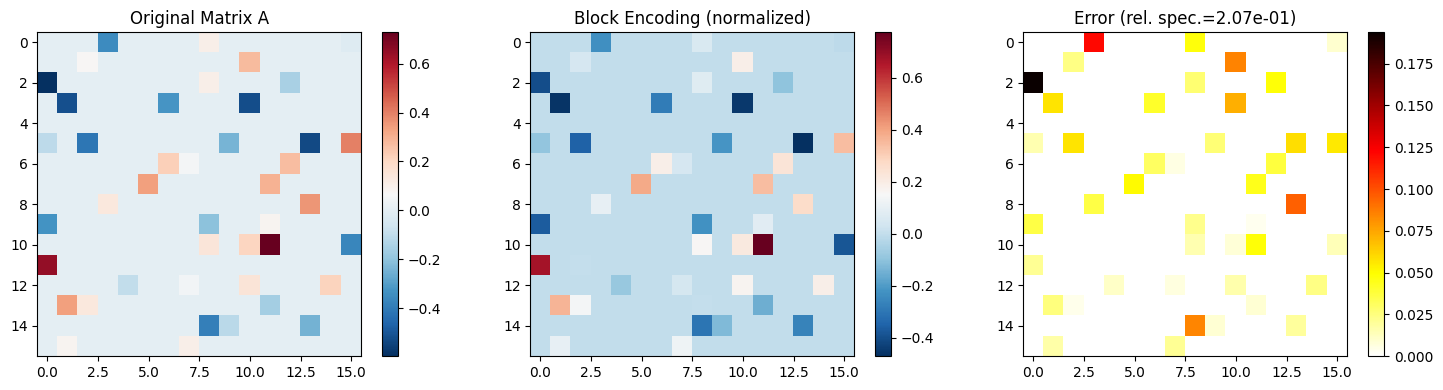

In [41]:
# Visualize block encoding result
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

A_np = np.array(A_full)
be_np = np.array(jnp.real(block_enc_normalized))
err_np = np.array(jnp.abs(block_enc_normalized - A_full))

im0 = axes[0].imshow(A_np, cmap='RdBu_r', aspect='equal')
axes[0].set_title('Original Matrix A')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(be_np, cmap='RdBu_r', aspect='equal')
axes[1].set_title('Block Encoding (normalized)')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(err_np, cmap='hot_r', aspect='equal')
axes[2].set_title(f'Error (rel. spec.={spec_error:.2e})')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

---
## Summary

This notebook demonstrated the core QOS primitives:

| Primitive | Input | Output | Key Function |
|-----------|-------|--------|--------------|
| Boolean Oracle | Truth table $f$ | Phase oracle $\text{diag}(e^{i\pi f})$ | `qos.q_oracle_sketch_boolean` |
| State Sketch | Vector $\mathbf{v}$ | State $|\psi_v\rangle$ | `qos.q_state_sketch` |
| Matrix Element Oracle | Sparse matrix $A$ | Element-wise block encoding | `qos.q_oracle_sketch_matrix_element` |
| Amplitude Amplification | Low-norm state | High-norm state | `primitives.amplitude_amplification` |
| Full Block Encoding | Sparse matrix $A$ | Block encoding via 3 oracles | `utils.block_encoding_from_sparse_oracles` |

### Key Takeaways
- QOS achieves **exponential memory advantage**: only $M$ random samples needed, independent of dataset size $N$
- Error scales as $\epsilon \sim O(M^{-0.5})$ for Boolean oracles
- QSVT provides the polynomial transformation framework
- Amplitude amplification boosts success probability to near 1

### References
- Paper: [arXiv:2604.07639](https://arxiv.org/abs/2604.07639)
- QSVT: [arXiv:2002.11649](https://arxiv.org/abs/2002.11649)
- Block encoding: [arXiv:1806.01838](https://arxiv.org/abs/1806.01838)